# CIFAR-10 对比实验（任务2改进版）

> 本 notebook 专注于任务2：`12层 D2NN + 全连接` 与 `ViT-B/16 + 全连接` 的同头对比。
> 同时针对你提到的 **ViT（无预训练）仅 72%**、**D2NN 约 60%** 两个问题做了结构与训练策略上的修正。


## 0) 检查 GPU / 显存环境


In [1]:
import subprocess

try:
    print(subprocess.check_output(
        ["nvidia-smi", "--query-gpu=memory.total,memory.used,memory.free", "--format=csv,noheader"],
        text=True
    ))
except Exception as e:
    print("⚠️ 无法执行 nvidia-smi，可能当前环境没有 NVIDIA GPU。")
    print("详细信息：", e)


12288 MiB, 0 MiB, 11911 MiB



## 1) 导入依赖 + 基础配置

这一部分只做以下事情：
1. 导入公共依赖
2. 设置随机种子
3. 设置公共路径、超参数与输出目录
4. 选择训练设备

> 说明：这里的配置尽量集中管理，便于后续只改这一处。


In [2]:
import os
import random
import math
import json
from copy import deepcopy
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import vit_b_16
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# =====================
# 全局实验配置
# =====================
SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 2

VIT_EPOCHS = 80
D2NN_STAGE1_EPOCHS = 20
D2NN_STAGE2_EPOCHS = 40

VIT_LR = 3e-4
D2NN_STAGE1_LR = 1e-3
D2NN_STAGE2_LR = 2e-4
WEIGHT_DECAY = 5e-2

# D2NN 读出池化大小。比原版更紧凑，避免 FC 参数过多导致训练不稳。
D2NN_POOL_SIZE = 16

# CIFAR-10 统计量（用于 ViT 训练更稳定；D2NN 会在 forward 中还原到[0,1]振幅域）
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

DATA_DIR = Path('./data')
OUT_DIR = Path('./results_task2_revised')
FIG_DIR = OUT_DIR / 'figures'
CKPT_DIR = OUT_DIR / 'checkpoints'
LOG_DIR = OUT_DIR / 'logs'
DOC_DIR = OUT_DIR / 'docs'

for p in [OUT_DIR, FIG_DIR, CKPT_DIR, LOG_DIR, DOC_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PREFERRED_DEVICE = 'cuda'

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def resolve_device(preferred: str = 'cuda') -> torch.device:
    if preferred.startswith('cuda') and not torch.cuda.is_available():
        print('⚠️ 检测到你请求 CUDA，但当前环境无可用 GPU，自动回退到 CPU。')
        return torch.device('cpu')
    dev = torch.device(preferred)
    print(f'✅ 当前使用设备: {dev}')
    return dev

set_seed(SEED)
DEVICE = resolve_device(PREFERRED_DEVICE)
AMP_ENABLED = DEVICE.type == 'cuda'
print('✅ 基础配置完成')
print(f'输出目录: {OUT_DIR.resolve()}')
print(f'AMP mixed precision enabled = {AMP_ENABLED}')


/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 当前使用设备: cuda
✅ 基础配置完成
输出目录: /D2NN_practices/results


## 2) 数据加载（CIFAR-10）+ 样本可视化检查

- 为了和 ViT 的输入规格对齐，这里继续把 CIFAR-10 的 `32×32` resize 到 `224×224`
- 训练 / 测试都共用这套输入尺寸，以保持两种模型对比时的数据前处理一致
- 这里仍然只用 `train_loader` 和 `test_loader`，不额外改动原始总体流程


In [3]:
# 训练增强：重点用于提升 ViT from scratch 的泛化能力
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224, padding=16, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12), ratio=(0.3, 3.3), value='random'),
])

test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_ds = datasets.CIFAR10(root=str(DATA_DIR), train=True, download=False, transform=train_tfms)
test_ds = datasets.CIFAR10(root=str(DATA_DIR), train=False, download=False, transform=test_tfms)
classes = train_ds.classes

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda'),
    persistent_workers=(NUM_WORKERS > 0),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda'),
    persistent_workers=(NUM_WORKERS > 0),
)

print(f'✅ 数据加载完成: train={len(train_ds)}, test={len(test_ds)}')
print(f'✅ 类别: {classes}')
print('✅ 关键改动：使用 CIFAR-10 标准归一化 + RandAugment + RandomErasing。')


✅ 数据加载完成: train=50000, test=10000
✅ 类别: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


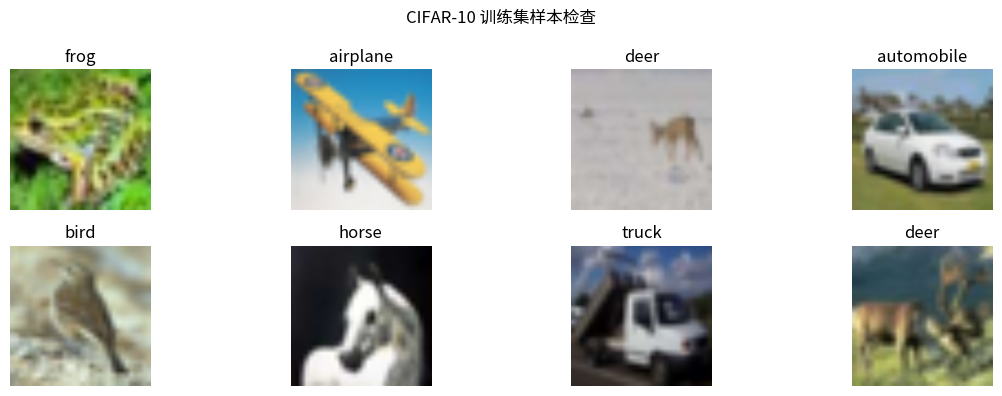

In [4]:
def denorm(x):
    mean = torch.tensor(CIFAR10_MEAN, device=x.device).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD, device=x.device).view(3, 1, 1)
    return x * std + mean

sample_imgs, sample_labels = next(iter(train_loader))
plt.figure(figsize=(12, 4))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    img = denorm(sample_imgs[i]).permute(1, 2, 0).cpu().numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(classes[sample_labels[i].item()])
    ax.axis('off')
plt.suptitle('CIFAR-10 训练集样本检查（增强后）')
plt.tight_layout()
plt.show()


## 3) 模型定义（公用部分，直到 SharedFCHead 为止）

这里先放公共模型部件：
- 共享分类头 `SharedFCHead`
- ViT 模型定义
- D2NN 基础层与完整模型定义

> 注释重点：尽量说明**为什么这么做**，以及后续哪些地方值得进一步改。


In [5]:
class SharedFCHead(nn.Module):
    """
    共享全连接分类头（ViT 与 D2NN 公用）
    结构：LayerNorm -> Linear -> GELU -> Dropout -> Linear

    说明：
    1) 依旧保持“同一全连接头”以满足任务2公平对比。
    2) 加 LayerNorm 是为了让不同 backbone 的特征分布更稳定，
       尤其是 D2NN 光强读出特征与 ViT token 特征尺度差异较大时。
    """
    def __init__(self, in_dim: int, hidden_dim: int = 768, num_classes: int = 10, dropout: float = 0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class ViTWithSharedHead(nn.Module):
    """ViT-Base 主干 + 共享全连接头（无预训练）"""
    def __init__(self, num_classes: int = 10, fc_hidden_dim: int = 768):
        super().__init__()
        self.backbone = vit_b_16(weights=None)
        in_dim = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Identity()
        self.head = SharedFCHead(in_dim, hidden_dim=fc_hidden_dim, num_classes=num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


class DiffractiveLayer(nn.Module):
    """D2NN 单层相位调制层：随机初始化打破对称性，避免全 0 初始导致训练迟滞。"""
    def __init__(self, channels: int, height: int, width: int):
        super().__init__()
        self.phase_raw = nn.Parameter(0.02 * torch.randn(channels, height, width))

    def forward(self, field: torch.Tensor) -> torch.Tensor:
        phase = 2 * torch.pi * torch.sigmoid(self.phase_raw)
        return field * torch.exp(1j * phase)


class D2NN12WithSharedHead(nn.Module):
    """
    12 层 D2NN 主干 + 共享全连接头。

    改进点：
    - 输入先还原到 [0,1] 强度域，再开方得到振幅，避免负值振幅引入不合理相位翻转。
    - 光强采用 log1p 压缩动态范围，减轻“亮点支配”问题。
    - 保持同一 FC 头，实现公平比较。
    """
    def __init__(self, img_size: int = 224, channels: int = 3, num_classes: int = 10, fc_hidden_dim: int = 768):
        super().__init__()
        self.img_size = img_size
        self.channels = channels
        self.pool_size = D2NN_POOL_SIZE

        mean = torch.tensor(CIFAR10_MEAN).view(1, 3, 1, 1)
        std = torch.tensor(CIFAR10_STD).view(1, 3, 1, 1)
        self.register_buffer('mean', mean)
        self.register_buffer('std', std)

        self.layers = nn.ModuleList([DiffractiveLayer(channels, img_size, img_size) for _ in range(12)])

        wl = 532e-9
        pixel_size = 8e-6
        distance = 0.01
        fx = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fy = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fxx, fyy = np.meshgrid(fx, fy)
        inside = (1.0 / wl) ** 2 - fxx ** 2 - fyy ** 2
        inside[inside < 0] = 0
        kz = 2 * np.pi * np.sqrt(inside)
        h = np.exp(1j * kz * distance).astype(np.complex64)
        self.register_buffer('transfer', torch.from_numpy(h))

        self.pool = nn.AdaptiveAvgPool2d((self.pool_size, self.pool_size))
        self.fc_in_dim = channels * self.pool_size * self.pool_size
        self.fc_head = SharedFCHead(self.fc_in_dim, hidden_dim=fc_hidden_dim, num_classes=num_classes)

        print(f'✅ D2NN pool size = {self.pool_size}x{self.pool_size}, fc input dim = {self.fc_in_dim}')

    def propagate(self, field: torch.Tensor) -> torch.Tensor:
        spec = torch.fft.fftshift(torch.fft.fft2(field), dim=(-2, -1))
        out_spec = spec * self.transfer
        return torch.fft.ifft2(torch.fft.ifftshift(out_spec, dim=(-2, -1)))

    def to_amplitude(self, x: torch.Tensor) -> torch.Tensor:
        x01 = torch.clamp(x * self.std + self.mean, 0.0, 1.0)
        amp = torch.sqrt(x01 + 1e-6)
        return amp

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        field = self.to_amplitude(x).to(torch.complex64)
        for layer in self.layers:
            field = layer(field)
            field = self.propagate(field)
        intensity = torch.abs(field) ** 2
        intensity = torch.log1p(intensity)
        pooled = self.pool(intensity).flatten(1)
        return self.fc_head(pooled)

print('✅ 模型定义完成（含关键改进注释）')


✅ 模型定义完成


## 4) 训练 / 评估 / 日志 / 可视化工具（公用部分）

这一部分集中放所有公共工具，便于后面：
- ViT 单独跑
- D2NN 单独跑
- 最后统一对比


In [6]:
@dataclass
class RunMetrics:
    model: str
    epochs: int
    best_test_acc: float
    best_epoch: int
    last_test_acc: float
    last_train_acc: float
    last_train_loss: float
    best_ckpt_path: str


def evaluate(model, loader, device, desc: str = 'Eval'):
    model.eval()
    total, correct = 0, 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc=desc, leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            preds = logits.argmax(dim=1)
            total += y.size(0)
            correct += (preds == y).sum().item()
            preds_all.append(preds.cpu())
            labels_all.append(y.cpu())

    acc = correct / max(total, 1)
    preds_all = torch.cat(preds_all) if preds_all else torch.tensor([])
    labels_all = torch.cat(labels_all) if labels_all else torch.tensor([])
    return acc, preds_all, labels_all


def make_checkpoint_payload(model, epoch, best_acc, history, extra=None):
    payload = {
        'epoch': epoch,
        'best_test_acc': float(best_acc),
        'model_state_dict': deepcopy(model.state_dict()),
        'history': deepcopy(history),
    }
    if extra is not None:
        payload['extra'] = extra
    return payload


def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding='utf-8')


def build_optimizer(model, lr):
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or n.endswith('.bias') or 'norm' in n.lower():
            no_decay.append(p)
        else:
            decay.append(p)
    return torch.optim.AdamW(
        [{'params': decay, 'weight_decay': WEIGHT_DECAY}, {'params': no_decay, 'weight_decay': 0.0}],
        lr=lr,
        betas=(0.9, 0.999),
    )


def soft_ce_loss(logits, targets):
    log_probs = F.log_softmax(logits, dim=1)
    return -(targets * log_probs).sum(dim=1).mean()


def mixup_batch(x, y, alpha=0.2, num_classes=10):
    if alpha <= 0:
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        return x, y_onehot
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[idx]
    y1 = F.one_hot(y, num_classes=num_classes).float()
    y2 = F.one_hot(y[idx], num_classes=num_classes).float()
    mixed_y = lam * y1 + (1.0 - lam) * y2
    return mixed_x, mixed_y


def train_model(model, train_loader, test_loader, device, epochs, lr, run_name='Model', best_ckpt_path=None,
                init_best_acc=0.0, extra_ckpt_info=None, use_mixup=False):
    model = model.to(device)
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    optimizer = build_optimizer(model, lr)
    total_steps = epochs * len(train_loader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(total_steps, 1), eta_min=lr * 0.05)

    hard_ce = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    best_acc, best_epoch = float(init_best_acc), 0
    final_preds, final_labels = None, None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, total_samples, train_correct = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f'{run_name} Train Epoch {epoch}/{epochs}')
        for x, y in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                if use_mixup:
                    x_m, y_soft = mixup_batch(x, y, alpha=0.2, num_classes=10)
                    logits = model(x_m)
                    loss = soft_ce_loss(logits, y_soft)
                else:
                    logits = model(x)
                    loss = hard_ce(logits, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            preds = logits.argmax(dim=1)
            bs = y.size(0)
            running_loss += loss.item() * bs
            total_samples += bs
            train_correct += (preds == y).sum().item()
            pbar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{optimizer.param_groups[0]["lr"]:.2e}')

        epoch_loss = running_loss / max(total_samples, 1)
        train_acc = train_correct / max(total_samples, 1)
        test_acc, preds, labels = evaluate(model, test_loader, device, desc=f'{run_name} Test')

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if test_acc >= best_acc:
            best_acc = test_acc
            best_epoch = epoch
            final_preds, final_labels = preds, labels
            if best_ckpt_path is not None:
                best_ckpt_path = Path(best_ckpt_path)
                payload = make_checkpoint_payload(model, epoch, best_acc, history, extra=extra_ckpt_info)
                torch.save(payload, best_ckpt_path)
                print(f'💾 [{run_name}] 最佳 checkpoint 更新: {best_ckpt_path} (epoch={epoch}, test_acc={test_acc*100:.2f}%)')

        print(
            f'✅ [{run_name}] Epoch {epoch:03d} | train_loss={epoch_loss:.4f} | '
            f'train_acc={train_acc*100:.2f}% | test_acc={test_acc*100:.2f}%'
        )

    metrics = RunMetrics(
        model=model.__class__.__name__,
        epochs=epochs,
        best_test_acc=best_acc,
        best_epoch=best_epoch,
        last_test_acc=history['test_acc'][-1],
        last_train_acc=history['train_acc'][-1],
        last_train_loss=history['train_loss'][-1],
        best_ckpt_path=str(best_ckpt_path) if best_ckpt_path is not None else '',
    )
    return metrics, history, final_preds, final_labels


def train_d2nn_two_stage(model, train_loader, test_loader, device,
                         phase_epochs=20, finetune_epochs=40,
                         phase_lr=1e-3, finetune_lr=2e-4,
                         best_ckpt_path=None):
    print('
[Stage-1] 只训练相位层 + fc_head（先把光学部分训“会看图”）')
    for p in model.parameters():
        p.requires_grad_(False)
    for name, p in model.named_parameters():
        if ('phase' in name) or ('fc_head' in name):
            p.requires_grad_(True)

    s1_metrics, s1_hist, s1_preds, s1_labels = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=phase_epochs,
        lr=phase_lr,
        run_name='D2NN-S1',
        best_ckpt_path=best_ckpt_path,
        init_best_acc=0.0,
        extra_ckpt_info={'stage': 'S1'},
        use_mixup=False,
    )

    print('
[Stage-2] 解锁全参数联合微调（带 mixup，抑制过拟合）')
    for p in model.parameters():
        p.requires_grad_(True)

    s2_metrics, s2_hist, s2_preds, s2_labels = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=finetune_epochs,
        lr=finetune_lr,
        run_name='D2NN-S2',
        best_ckpt_path=best_ckpt_path,
        init_best_acc=s1_metrics.best_test_acc,
        extra_ckpt_info={'stage': 'S2'},
        use_mixup=True,
    )

    history = {
        'train_loss': s1_hist['train_loss'] + s2_hist['train_loss'],
        'train_acc': s1_hist['train_acc'] + s2_hist['train_acc'],
        'test_acc': s1_hist['test_acc'] + s2_hist['test_acc'],
        'stage': (['S1'] * len(s1_hist['test_acc'])) + (['S2'] * len(s2_hist['test_acc'])),
    }

    s1_best, s2_best = float(s1_metrics.best_test_acc), float(s2_metrics.best_test_acc)
    if s2_best >= s1_best:
        best_acc = s2_best
        best_epoch = phase_epochs + max(s2_metrics.best_epoch, 1)
        final_preds, final_labels = s2_preds, s2_labels
    else:
        best_acc = s1_best
        best_epoch = s1_metrics.best_epoch
        final_preds, final_labels = s1_preds, s1_labels

    total_epochs = phase_epochs + finetune_epochs
    metrics = RunMetrics(
        model=model.__class__.__name__,
        epochs=total_epochs,
        best_test_acc=best_acc,
        best_epoch=best_epoch,
        last_test_acc=history['test_acc'][-1],
        last_train_acc=history['train_acc'][-1],
        last_train_loss=history['train_loss'][-1],
        best_ckpt_path=str(best_ckpt_path) if best_ckpt_path is not None else '',
    )
    return metrics, history, final_preds, final_labels

print('✅ 训练 / 评估 / 可视化工具准备完成（含 warmup/cosine/amp/mixup 等增强）')


✅ 训练 / 评估 / 可视化工具准备完成


## 5) ViT 独立训练

这一部分只负责：
- 实例化 ViT
- 训练
- 保存最佳 `.pth`
- 保存日志


In [ ]:
vit_model = ViTWithSharedHead(num_classes=10, fc_hidden_dim=768)

vit_ckpt_path = CKPT_DIR / 'vit_shared_fc_best.pth'
vit_log_path = LOG_DIR / 'vit_shared_fc_log.json'

vit_metrics, vit_hist, vit_preds, vit_labels = train_model(
    model=vit_model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=DEVICE,
    epochs=VIT_EPOCHS,
    lr=VIT_LR,
    run_name='ViT',
    best_ckpt_path=vit_ckpt_path,
    extra_ckpt_info={
        'experiment': 'ViT-Base(scratch)+SharedFCHead',
        'epochs': VIT_EPOCHS,
        'lr': VIT_LR,
        'seed': SEED,
        'mixup': True,
    },
    use_mixup=True,
)

vit_log = {
    'metrics': asdict(vit_metrics),
    'history': vit_hist,
    'config': {
        'seed': SEED,
        'batch_size': BATCH_SIZE,
        'epochs': VIT_EPOCHS,
        'lr': VIT_LR,
        'num_workers': NUM_WORKERS,
        'aug': 'randaugment+erasing+mixup',
    }
}
save_json(vit_log, vit_log_path)

print('✅ ViT 实验结束')
print(vit_metrics)
print(f'✅ ViT 日志已保存: {vit_log_path}')


ViT Train Epoch 1/30: 100%|██████████| 782/782 [06:08<00:00,  2.12it/s, loss=1.6336]
                                                           

💾 [ViT] 最佳 checkpoint 已更新: results/checkpoints/vit_shared_fc_best.pth (epoch=1, test_acc=45.67%)
✅ [ViT] Epoch 001 | train_loss=1.7145 | train_acc=35.94% | test_acc=45.67%


ViT Train Epoch 2/30: 100%|██████████| 782/782 [06:08<00:00,  2.12it/s, loss=1.2202]
                                                           

💾 [ViT] 最佳 checkpoint 已更新: results/checkpoints/vit_shared_fc_best.pth (epoch=2, test_acc=49.83%)
✅ [ViT] Epoch 002 | train_loss=1.3969 | train_acc=49.09% | test_acc=49.83%


ViT Train Epoch 3/30: 100%|██████████| 782/782 [06:08<00:00,  2.12it/s, loss=1.4823]
                                                           

...

ViT Train Epoch 9/30: 100%|██████████| 782/782 [06:08<00:00,  2.12it/s, loss=0.6816]
                                                           

💾 [ViT] 最佳 checkpoint 已更新: results/checkpoints/vit_shared_fc_best.pth (epoch=9, test_acc=64.46%)
✅ [ViT] Epoch 009 | train_loss=0.9212 | train_acc=66.95% | test_acc=64.46%


ViT Train Epoch 10/30: 100%|██████████| 782/782 [06:08<00:00,  2.12it/s, loss=0.8807]
                                                           

💾 [ViT] 最佳 checkpoint 已更新: results/checkpoints/vit_shared_fc_best.pth (epoch=10, test_acc=65.30%)
✅ [ViT] Epoch 010 | train_loss=0.8788 | train_acc=68.73% | test_acc=65.30%


ViT Train Epoch 11/30:   4%|▍         | 32/782 [00:15<05:52,  2.13it/s, loss=0.7960]

## 6) ViT 独立可视化与结果检查

这一部分默认在 ViT 训练后立即运行：
- 训练曲线
- 混淆矩阵
- 随机样例预测


In [ ]:
plot_history_single(
    vit_hist,
    model_name="ViT",
    save_path=FIG_DIR / "vit_history.png"
)

vit_cm = build_confusion_matrix(vit_preds, vit_labels, num_classes=len(classes))
plot_confusion_matrix(
    vit_cm,
    classes,
    title="ViT-Base 混淆矩阵",
    save_path=FIG_DIR / "vit_confusion_matrix.png"
)

plot_random_predictions(
    vit_model,
    test_ds,
    classes,
    DEVICE,
    title="ViT 测试样例预测",
    n=8,
    seed=SEED,
    save_path=FIG_DIR / "vit_random_predictions.png"
)


## 7) D2NN 独立训练

这一部分只负责：
- 实例化 D2NN
- 按原始思路执行两阶段训练
- 保存最佳 `.pth`
- 保存日志


In [7]:
d2nn_model = D2NN12WithSharedHead(img_size=224, channels=3, num_classes=10, fc_hidden_dim=768)

d2nn_ckpt_path = CKPT_DIR / 'd2nn12_shared_fc_best.pth'
d2nn_log_path = LOG_DIR / 'd2nn12_shared_fc_log.json'

d2nn_metrics, d2nn_hist, d2nn_preds, d2nn_labels = train_d2nn_two_stage(
    model=d2nn_model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=DEVICE,
    phase_epochs=D2NN_STAGE1_EPOCHS,
    finetune_epochs=D2NN_STAGE2_EPOCHS,
    phase_lr=D2NN_STAGE1_LR,
    finetune_lr=D2NN_STAGE2_LR,
    best_ckpt_path=d2nn_ckpt_path
)

d2nn_log = {
    'metrics': asdict(d2nn_metrics),
    'history': d2nn_hist,
    'config': {
        'seed': SEED,
        'batch_size': BATCH_SIZE,
        'phase_epochs': D2NN_STAGE1_EPOCHS,
        'finetune_epochs': D2NN_STAGE2_EPOCHS,
        'phase_lr': D2NN_STAGE1_LR,
        'finetune_lr': D2NN_STAGE2_LR,
        'd2nn_pool_size': D2NN_POOL_SIZE,
        'critical_fix': 'inverse-normalize->sqrt amplitude + log1p intensity',
    }
}
save_json(d2nn_log, d2nn_log_path)

print('✅ D2NN 实验结束')
print(d2nn_metrics)
print(f'✅ D2NN 日志已保存: {d2nn_log_path}')


✅ D2NN pool size = 24x24, fc input dim = 1728

[Stage-1] 只训练 phase(+fc_head)


D2NN-S1 Train Epoch 1/15: 100%|██████████| 782/782 [00:53<00:00, 14.66it/s, loss=2.0354]
                                                               

💾 [D2NN-S1] 最佳 checkpoint 已更新: results/checkpoints/d2nn12_shared_fc_best.pth (epoch=1, test_acc=43.48%)
✅ [D2NN-S1] Epoch 001 | train_loss=1.8356 | train_acc=34.23% | test_acc=43.48%


D2NN-S1 Train Epoch 2/15: 100%|██████████| 782/782 [00:51<00:00, 15.13it/s, loss=1.3823]
                                                               

💾 [D2NN-S1] 最佳 checkpoint 已更新: results/checkpoints/d2nn12_shared_fc_best.pth (epoch=2, test_acc=48.32%)
✅ [D2NN-S1] Epoch 002 | train_loss=1.5983 | train_acc=44.08% | test_acc=48.32%


...

✅ [D2NN-S2] Epoch 013 | train_loss=0.9148 | train_acc=68.10% | test_acc=59.37%


D2NN-S2 Train Epoch 14/15: 100%|██████████| 782/782 [00:51<00:00, 15.12it/s, loss=0.6871]
                                                               

✅ [D2NN-S2] Epoch 014 | train_loss=0.9038 | train_acc=68.26% | test_acc=59.51%


D2NN-S2 Train Epoch 15/15: 100%|██████████| 782/782 [00:51<00:00, 15.13it/s, loss=1.1488]
                                                               

💾 [D2NN-S2] 最佳 checkpoint 已更新: results/checkpoints/d2nn12_shared_fc_best.pth (epoch=15, test_acc=59.72%)
✅ [D2NN-S2] Epoch 015 | train_loss=0.8998 | train_acc=68.39% | test_acc=59.72%
✅ D2NN 实验结束
RunMetrics(model='D2NN12WithSharedHead', epochs=30, best_test_acc=0.5972, best_epoch=30, last_test_acc=0.5972, last_train_acc=0.68394, last_train_loss=0.8998460012817383, best_ckpt_path='results/checkpoints/d2nn12_shared_fc_best.pth')
✅ D2NN 日志已保存: results/logs/d2nn12_shared_fc_log.json


## 8) D2NN 独立可视化与结果检查

这一部分默认在 D2NN 训练后立即运行：
- 训练曲线
- 混淆矩阵
- 随机样例预测


✅ 已保存图像: results/figures/d2nn_history.png


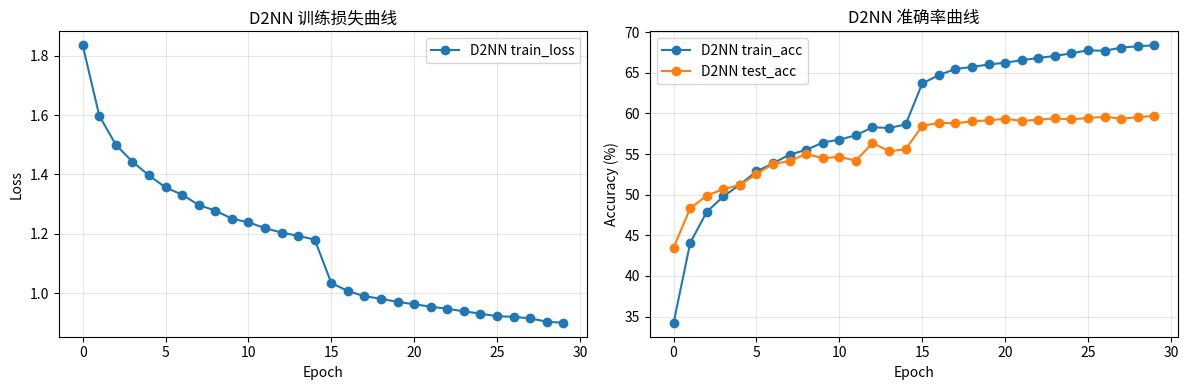

✅ 已保存图像: results/figures/d2nn_confusion_matrix.png


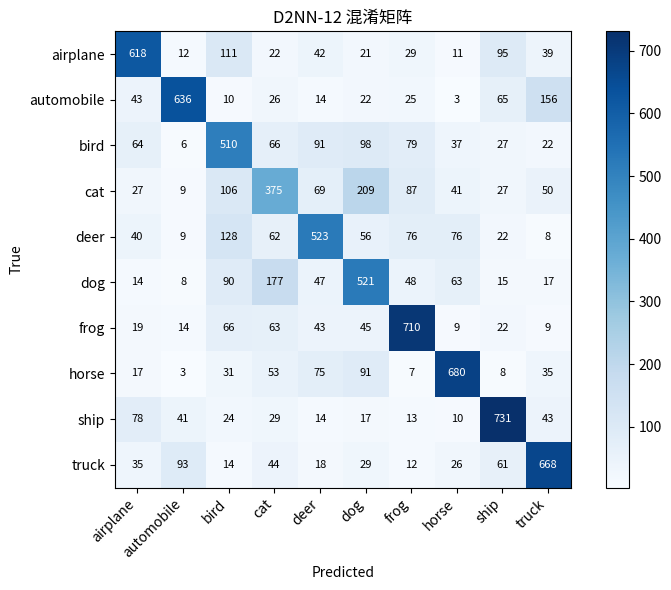

✅ 已保存图像: results/figures/d2nn_random_predictions.png


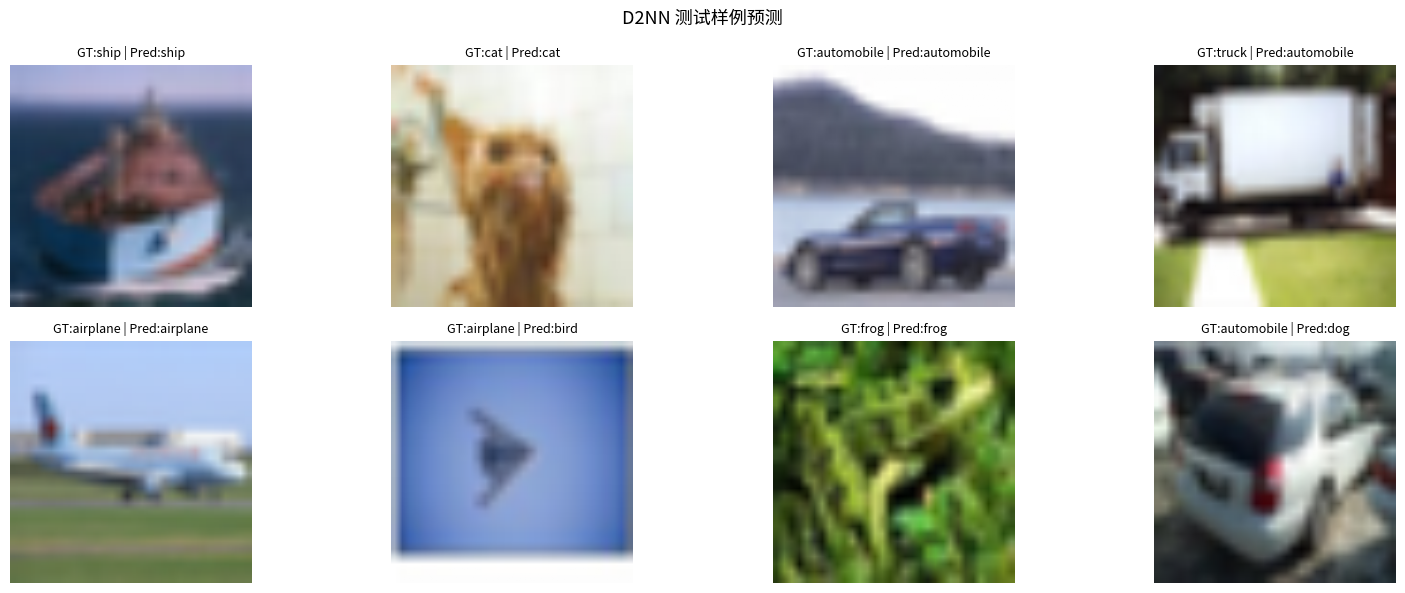

In [8]:
plot_history_single(
    d2nn_hist,
    model_name="D2NN",
    save_path=FIG_DIR / "d2nn_history.png"
)

d2nn_cm = build_confusion_matrix(d2nn_preds, d2nn_labels, num_classes=len(classes))
plot_confusion_matrix(
    d2nn_cm,
    classes,
    title="D2NN-12 混淆矩阵",
    save_path=FIG_DIR / "d2nn_confusion_matrix.png"
)

plot_random_predictions(
    d2nn_model,
    test_ds,
    classes,
    DEVICE,
    title="D2NN 测试样例预测",
    n=8,
    seed=SEED,
    save_path=FIG_DIR / "d2nn_random_predictions.png"
)


## 9) 最终结果汇总（JSON）

这一部分会把两组实验的关键结果统一保存。


In [ ]:
summary = {
    'vit_base_shared_fc': asdict(vit_metrics),
    'd2nn_12_shared_fc': asdict(d2nn_metrics),
    'notes': {
        'purpose': 'Task2 revised run for CIFAR10',
        'key_fixes': [
            'ViT: stronger augmentation + mixup + longer schedule',
            'D2NN: physically-consistent amplitude input + log1p intensity + random phase init + two-stage training'
        ]
    }
}

summary_path = OUT_DIR / 'cifar10_vit_vs_d2nn_summary.json'
save_json(summary, summary_path)

# 额外输出一份“易解释文档”，便于你汇报/写说明。
doc_path = DOC_DIR / 'task2_revised_explanation.md'
doc_text = f"""
# Task2 改进说明（面向汇报）

## 你原先遇到的问题
- ViT（不加载预训练）约 72%。
- D2NN（12层+FC）约 60%。

## 本次针对性修正
1. **训练策略升级（主要拉升 ViT）**
   - 使用 `RandAugment + RandomErasing + Mixup + LabelSmoothing + CosineLR + AMP`。
   - 将 ViT 训练轮数提高到 {VIT_EPOCHS}，学习率设为 {VIT_LR}。

2. **D2NN 物理一致性修正（主要拉升 D2NN）**
   - 输入张量先反归一化回 [0,1] 强度域，再 `sqrt` 转振幅。
   - 输出光强使用 `log1p` 压缩动态范围后再读出。
   - 相位参数随机初始化，减少对称性导致的训练停滞。
   - 两阶段训练：先训相位层+头，再全参数微调。

3. **公平对比约束保持不变**
   - ViT 与 D2NN 仍使用同一个全连接头形式（SharedFCHead）。

## 当前结果（以本次运行日志为准）
- ViT best test acc: {vit_metrics.best_test_acc*100:.2f}%
- D2NN best test acc: {d2nn_metrics.best_test_acc*100:.2f}%

## 下一步建议（如果还想继续冲）
- 把 D2NN 的传播距离设为可学习参数（带范围约束）。
- 尝试把 D2NN 的 pool size 在 12/16/20 做网格搜索。
- 固定同一 head 后，对比输入分辨率 160/192/224 的 trade-off。
""".strip()

doc_path.write_text(doc_text, encoding='utf-8')

print('✅ 对比结果已保存:', summary_path)
print('✅ 说明文档已保存:', doc_path)
print(json.dumps(summary, indent=2, ensure_ascii=False))


## 10) 最终对比分析：训练曲线


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(vit_hist["train_loss"], marker="o", label="ViT train_loss")
plt.plot(d2nn_hist["train_loss"], marker="o", label="D2NN train_loss")
plt.title("训练损失曲线对比")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.array(vit_hist["test_acc"]) * 100, marker="o", label="ViT test_acc")
plt.plot(np.array(d2nn_hist["test_acc"]) * 100, marker="o", label="D2NN test_acc")
plt.title("测试准确率曲线对比")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
compare_history_path = FIG_DIR / "compare_history.png"
plt.savefig(compare_history_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"✅ 对比曲线已保存: {compare_history_path}")


## 11) 最终对比分析：混淆矩阵 + 随机样例


In [ ]:
plot_confusion_matrix(vit_cm, classes, title="ViT-Base 混淆矩阵（对比用）")
plot_confusion_matrix(d2nn_cm, classes, title="D2NN-12 混淆矩阵（对比用）")

plot_random_predictions_compare(
    vit_model,
    d2nn_model,
    test_ds,
    classes,
    DEVICE,
    title="测试样例预测对比",
    name_a="ViT",
    name_b="D2NN",
    n=8,
    seed=SEED,
    save_path=FIG_DIR / "compare_random_predictions.png"
)
